In [1]:
# ================================================================
# MASTER BATTERY ANALYSIS CODE — VOLTAIQ ANALYTICS STUDIO
# ================================================================
# Analyses included:
#   1. Cycle Series — RTE, SOH, capacity, energy, coulombic
#      efficiency, energy inefficiency, relative metrics,
#      time & capacity weighted ΔV, max charge/discharge temperature
#   2. Ambient Temperature — full raw time series (T1 channel)
#   3. DCIR — 10s DCR at 50% SOC, SOC-weighted 10s DCR,
#              relative versions of both; raw ΔV and resistance
#              at 1s, 10s, 60s across all SOC levels
#
# Instructions:
#   1. Edit CELL 2 (User Configuration) before running anything
#   2. Run cells in order: Cell 1 → Cell 8
#   3. Results are exported to a multi-sheet Excel file
# ================================================================



# ================================================================
# CELL 1 — IMPORTS
# ================================================================

import pandas as pd
import voltaiq_studio as vs
import numpy as np
from scipy import interpolate

In [2]:
# ================================================================
# CELL 2 — USER CONFIGURATION
# Edit ALL values in this cell before running the analysis.
# ================================================================
 
# --- Test names ---
# Must match Voltaiq names exactly (case-insensitive substring match).
test_names = [
    'CV_0006_DV2A184_Pr_CyLT_25C', #Reference file #1
    'CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V-UCV_15C', #beta
    'CV_0013_CS2D0970_Pr_FoamStack-Alpha-25cyc-3.25V-UCV_15C', #alpha
    #'CV_0013_CS2D8992_Pr_CyLT-3.25V-UCV-50cyc_20C',
    #'CV_0013_CS2D8859_Pr_CyLT-3.25V-UCV-100cyc-1_20C',
    #'CV_0010_CS2D9802_Pr_RPT_25C',
    #'CV_0010_CS2D1050_Pr_RPT_25C',
    #'CV_0010_CS2D6616_Pr_RPT_25C',
    # Add or remove test names as needed.
]
 
# --- Cycles to skip (applied to all cycle-based analyses) ---
skip_cycles = [0]
 
# --- Reference cycles for relative metrics ---
# Each relative metric has its own configurable reference cycle.
ref_cycle_soh                       = 2    # Relative discharge capacity (SOH)
ref_cycle_relative_discharge_energy = 2    # Relative discharge energy
ref_cycle_relative_rte              = 2    # Relative energy efficiency / inefficiency
ref_cycle_delta_v                   = 2    # Relative ΔV metrics
ref_cycle_dcir                      = 4    # Relative DCIR metrics
ref_cycle_thickness                 = 1    # Relative thickness
 
# --- DCIR parameters ---
test_current = 38.8     # Amps — pulse current used to calculate resistance (R = ΔV / I)
target_times = [0, 1, 10, 60]  # seconds — time points at which to sample voltage
 
# Cycles at which DCIR pulses were conducted.
# The step numbers below will be applied to every cycle listed here.
dcir_cycles = [4, 109, 214, 319]  # add or remove cycles as needed
 
# Step numbers for discharge and charge pulses — same pattern applies
# to every cycle in dcir_cycles above.
discharge_steps = [17, 21, 28, 35, 42, 49, 56, 63, 70, 77, 84, 91, 98]
charge_steps    = [17, 24, 31, 38, 45, 52, 59, 66, 73, 80, 87, 94, 98]
 
# SOC labels mapped to (pre-pulse step, pulse step) pairs.
# Adjust step numbers to match your test protocol.
step_pairs_Dis = {
    '100SOC': (16, 17), '95SOC':  (20, 21), '90SOC':  (27, 28),
    '80SOC':  (34, 35), '70SOC':  (41, 42), '60SOC':  (48, 49),
    '50SOC':  (55, 56), '40SOC':  (62, 63), '30SOC':  (69, 70),
    '20SOC':  (76, 77), '10SOC':  (83, 84), '5SOC':   (90, 91),
    '0SOC':   (97, 98),
}
step_pairs_Char = {
    '100SOC': (16, 17), '95SOC':  (23, 24), '90SOC':  (30, 31),
    '80SOC':  (37, 38), '70SOC':  (44, 45), '60SOC':  (51, 52),
    '50SOC':  (58, 59), '40SOC':  (65, 66), '30SOC':  (72, 73),
    '20SOC':  (79, 80), '10SOC':  (86, 87), '5SOC':   (93, 94),
    '0SOC':   (97, 98),
}
 
# --- Analysis toggles ---
# Set to False to skip an analysis entirely. Skipped analyses will
# populate their columns with NAN in the output Excel file.
run_dcir = False
 
# --- Output ---
output_filename = 'battery_analysis_results_v10.xlsx'
 

In [3]:
# ================================================================
# CELL 3 — UTILITY & ANALYSIS FUNCTIONS
# Run this cell once to define all functions before executing analyses.
# ================================================================
 
def filter_test_record_by_name(name_fragment, trs):
    """Case-insensitive substring match against all loaded test records."""
    return [t for t in trs if name_fragment.lower() in t.name.lower()]
 
 
# ----------------------------------------------------------------
# CYCLE SERIES ANALYSIS
# Computes per-cycle summary metrics for one Voltaiq test record.
# ----------------------------------------------------------------
def calculate_cycle_series_metrics(
    tr,
    skip_cycles,
    ref_cycle_soh,
    ref_cycle_relative_discharge_energy,
    ref_cycle_relative_rte,
    ref_cycle_delta_v,
    ref_cycle_thickness,
):
    """
    Calculate per-cycle summary metrics for a single Voltaiq test record.
 
    Parameters
    ----------
    tr                                  : Voltaiq test record
    skip_cycles                         : list[int] — cycle numbers to exclude
    ref_cycle_soh                       : int — reference cycle for SOH
    ref_cycle_relative_discharge_energy : int — reference cycle for relative
                                              discharge energy
    ref_cycle_relative_rte              : int — reference cycle for relative
                                              energy efficiency / inefficiency
    ref_cycle_delta_v                   : int — reference cycle for relative
                                              ΔV metrics
 
    Returns
    -------
    pd.DataFrame with one row per valid cycle.
    """
    print(f"\n🔍 Processing cycle series: {tr.name}")
 
    base_keys = [
        'h_cycle',
        'h_test_time',
        'h_charge_capacity',
        'h_discharge_capacity',
        'h_charge_energy',
        'h_discharge_energy',
        'h_potential',
    ]
    # Try adding optional trace keys one at a time so a missing channel
    # in one test does not prevent other channels from being read.
    optional_keys  = {
        'aux_neware_xls_t2_none_0':        'has_cell_temp',
        'aux_neware_xls_thickness_mm_0':   'has_thickness',
    }
    available_optional = {}
    for key, flag in optional_keys.items():
        reader_test = tr.make_time_series_reader()
        try:
            reader_test.add_trace_keys(*base_keys, key)
            available_optional[key] = True
        except Exception:
            print(f"  ⚠️ '{key}' not found for {tr.name} — column will be NAN.")
            available_optional[key] = False
 
    has_cell_temp = available_optional['aux_neware_xls_t2_none_0']
    has_thickness = available_optional['aux_neware_xls_thickness_mm_0']
 
    # Build the final key list with only the available optional channels.
    final_keys = base_keys + [k for k, v in available_optional.items() if v]
    reader = tr.make_time_series_reader()
    reader.add_trace_keys(*final_keys)
 
    df = reader.read_pandas()
    df = df.dropna(subset=['h_cycle'])
    cycles = sorted(df['h_cycle'].unique())
 
    # Helper: get max value of a column at a given reference cycle.
    def get_ref_max(ref_cycle, col):
        df_ref = df[df['h_cycle'] == ref_cycle]
        if df_ref.empty:
            print(f"  ⚠️ Reference cycle {ref_cycle} not found for '{col}'. "
                  f"Relative metrics using this reference will be None.")
            return None
        val = df_ref[col].max()
        return val if pd.notna(val) and val > 0 else None
 
    # Pre-compute reference values used across all cycles.
    ref_discharge_cap        = get_ref_max(ref_cycle_soh,
                                           'h_discharge_capacity')
    ref_discharge_energy_re  = get_ref_max(ref_cycle_relative_discharge_energy,
                                           'h_discharge_energy')
    ref_charge_energy_rte    = get_ref_max(ref_cycle_relative_rte,
                                           'h_charge_energy')
    ref_discharge_energy_rte = get_ref_max(ref_cycle_relative_rte,
                                           'h_discharge_energy')
    ref_thickness            = (
        get_ref_max(ref_cycle_thickness, 'aux_neware_xls_thickness_mm_0')
        if has_thickness else None
    )
 
    if ref_charge_energy_rte and ref_discharge_energy_rte:
        ref_rte                 = ref_discharge_energy_rte / ref_charge_energy_rte
        ref_energy_inefficiency = 1 - ref_rte
    else:
        ref_rte                 = None
        ref_energy_inefficiency = None
 
    results = []
 
    for cycle in cycles:
        if cycle in skip_cycles:
            continue
 
        df_cycle = df[df['h_cycle'] == cycle]
 
        # Time
        cumulative_time_s = df_cycle['h_test_time'].max()
        time_days = cumulative_time_s / 86400 if pd.notna(cumulative_time_s) else None
 
        # Capacity
        charge_cap    = df_cycle['h_charge_capacity'].max()
        discharge_cap = df_cycle['h_discharge_capacity'].max()
 
        # Coulombic efficiency
        coulombic_eff = (
            discharge_cap / charge_cap
            if (pd.notna(charge_cap) and charge_cap > 0 and pd.notna(discharge_cap))
            else None
        )
 
        # SOH (relative discharge capacity)
        soh = (
            discharge_cap / ref_discharge_cap
            if (ref_discharge_cap and pd.notna(discharge_cap))
            else None
        )
 
        # Energy
        charge_energy    = df_cycle['h_charge_energy'].max()
        discharge_energy = df_cycle['h_discharge_energy'].max()
 
        # RTE and energy inefficiency computed together to share the
        # rte_fraction value and avoid any None arithmetic issues.
        if (pd.notna(charge_energy) and charge_energy > 0
                and pd.notna(discharge_energy)):
            rte_fraction        = discharge_energy / charge_energy
            rte                 = rte_fraction
            energy_inefficiency = 1 - rte_fraction
        else:
            rte                 = None
            energy_inefficiency = None
 
        # Relative discharge energy
        rel_discharge_energy = (
            discharge_energy / ref_discharge_energy_re
            if (ref_discharge_energy_re and pd.notna(discharge_energy))
            else None
        )
 
        # Relative energy efficiency
        rel_energy_efficiency = (
            rte / ref_rte
            if (rte is not None and ref_rte)
            else None
        )
 
        # Relative energy inefficiency
        rel_energy_inefficiency = (
            energy_inefficiency / ref_energy_inefficiency
            if (energy_inefficiency is not None and ref_energy_inefficiency)
            else None
        )
 
        # Separate charge and discharge phases for temperature and ΔV.
        df_chg_phase = (
            df_cycle[df_cycle['h_charge_capacity'] > 0]
            .dropna(subset=['h_potential', 'h_test_time', 'h_charge_capacity'])
        )
        df_dis_phase = (
            df_cycle[df_cycle['h_discharge_capacity'] > 0]
            .dropna(subset=['h_potential', 'h_test_time', 'h_discharge_capacity'])
        )
 
        # Thickness — mean per cycle
        if has_thickness and 'aux_neware_xls_thickness_mm_0' in df.columns:
            thickness = df_cycle['aux_neware_xls_thickness_mm_0'].mean()
            rel_thickness = (
                thickness / ref_thickness
                if (ref_thickness and pd.notna(thickness))
                else None
            )
        else:
            thickness     = None
            rel_thickness = None
 
        # Max temperatures
        if has_cell_temp and 'aux_neware_xls_t2_none_0' in df.columns:
            max_charge_temp = (
                df_chg_phase['aux_neware_xls_t2_none_0'].max()
                if not df_chg_phase.empty else None
            )
            max_discharge_temp = (
                df_dis_phase['aux_neware_xls_t2_none_0'].max()
                if not df_dis_phase.empty else None
            )
        else:
            max_charge_temp    = None
            max_discharge_temp = None
 
        # ΔV calculations
        cap_weighted_delta_v  = None
        time_weighted_delta_v = None
 
        # Drop duplicate x-values before interpolation to prevent scipy
        # divide-by-zero warnings when two points share the same capacity
        # or time value.
        df_chg_sorted = (df_chg_phase.sort_values('h_charge_capacity')
                         .drop_duplicates(subset=['h_charge_capacity']))
        df_dis_sorted = (df_dis_phase.sort_values('h_discharge_capacity')
                         .drop_duplicates(subset=['h_discharge_capacity']))
 
        if len(df_chg_sorted) > 1 and len(df_dis_sorted) > 1:
            q_chg = df_chg_sorted['h_charge_capacity'].values
            v_chg = df_chg_sorted['h_potential'].values
            q_dis = df_dis_sorted['h_discharge_capacity'].values
            v_dis = df_dis_sorted['h_potential'].values
 
            # Capacity weighted ΔV:
            # Interpolate V_discharge and V_charge onto a common capacity grid,
            # compute (V_dis - V_chg) at each point, then take the
            # capacity-weighted average. Converted V → mV.
            q_min = max(q_chg.min(), q_dis.min())
            q_max = min(q_chg.max(), q_dis.max())
            if q_max > q_min:
                q_common  = np.linspace(q_min, q_max, 500)
                f_chg_q   = interpolate.interp1d(q_chg, v_chg,
                                bounds_error=False, fill_value='extrapolate')
                f_dis_q   = interpolate.interp1d(q_dis, v_dis,
                                bounds_error=False, fill_value='extrapolate')
                delta_v_q = f_chg_q(q_common) - f_dis_q(q_common)
                cap_weighted_delta_v = (
                    np.trapz(delta_v_q, q_common) / (q_max - q_min) * 1000
                )
 
            # Time weighted ΔV:
            # Compute the time-weighted mean voltage for charge and discharge
            # independently, then subtract. This matches the standard approach
            # of (time-weighted mean V_charge) − (time-weighted mean V_discharge).
            # No cross-curve interpolation is needed or applied.
            t_chg       = df_chg_sorted['h_test_time'].values
            t_dis       = df_dis_sorted['h_test_time'].values
            t_chg_range = t_chg.max() - t_chg.min()
            t_dis_range = t_dis.max() - t_dis.min()
            if t_chg_range > 0 and t_dis_range > 0:
                v_chg_mean = np.trapz(v_chg, t_chg) / t_chg_range
                v_dis_mean = np.trapz(v_dis, t_dis) / t_dis_range
                time_weighted_delta_v = (v_chg_mean - v_dis_mean) * 1000  # V → mV
 
        results.append({
            'Test Name':                        tr.name,
            'Cycle':                            cycle,
            'Time (days)':                      time_days,
            'Charge capacity (Ah)':             charge_cap,
            'Discharge capacity (Ah)':          discharge_cap,
            'Relative discharge capacity':                          soh,
            'Coulombic efficiency':         coulombic_eff,
            'Charge energy (Wh)':           charge_energy,
            'Discharge energy (Wh)':        discharge_energy,
            'Energy efficiency':                          rte,
            'Energy inefficiency':          energy_inefficiency,
            'Relative discharge energy':    rel_discharge_energy,
            'Relative energy efficiency':   rel_energy_efficiency,
            'Relative energy inefficiency': rel_energy_inefficiency,
            'Capacity weighted ΔV (mV)':        cap_weighted_delta_v,
            'Time weighted ΔV (mV)':            time_weighted_delta_v,
            'Max charge temperature (°C)':      max_charge_temp,
            'Max discharge temperature (°C)':   max_discharge_temp,
            'Thickness (mm)':                   thickness,
            'Relative thickness':               rel_thickness,
        })
 
    cycle_df = pd.DataFrame(results)
 
    # Relative ΔV is computed after the loop because it requires the
    # reference row, which is only available once all cycles are processed.
    if not cycle_df.empty and ref_cycle_delta_v in cycle_df['Cycle'].values:
        ref_row     = cycle_df[cycle_df['Cycle'] == ref_cycle_delta_v].iloc[0]
        ref_cap_dv  = ref_row['Capacity weighted ΔV (mV)']
        ref_time_dv = ref_row['Time weighted ΔV (mV)']
 
        cycle_df['Relative capacity weighted ΔV'] = (
            cycle_df['Capacity weighted ΔV (mV)'] / ref_cap_dv
            if (pd.notna(ref_cap_dv) and ref_cap_dv != 0) else None
        )
        cycle_df['Relative time weighted ΔV'] = (
            cycle_df['Time weighted ΔV (mV)'] / ref_time_dv
            if (pd.notna(ref_time_dv) and ref_time_dv != 0) else None
        )
    else:
        print(f"  ⚠️ Reference cycle {ref_cycle_delta_v} not found — "
              f"relative ΔV metrics set to None.")
        cycle_df['Relative capacity weighted ΔV'] = None
        cycle_df['Relative time weighted ΔV']     = None
 
    return cycle_df
 
 
# ----------------------------------------------------------------
# AMBIENT TEMPERATURE TIME SERIES
# Reads raw T1 ambient temperature data for one test record.
# ----------------------------------------------------------------
def read_ambient_temperature_time_series(tr, skip_cycles):
    """
    Read ambient temperature (T1) time series for a single Voltaiq test record.
 
    Returns
    -------
    pd.DataFrame with columns:
        Test Name, Cycle, Test Time (s), Time (days), Ambient Temperature (°C)
    """
    print(f"\n🔍 Processing ambient temperature: {tr.name}")
 
    reader = tr.make_time_series_reader()
    try:
        reader.add_trace_keys(
            'h_cycle',
            'h_test_time',
            'aux_neware_xls_t1_none_0',  # ambient temperature (T1)
        )
    except Exception:
        print(f"  ⚠️ No ambient temperature data for {tr.name} — "
              f"returning empty DataFrame.")
        return pd.DataFrame(columns=[
            'Test Name', 'Cycle', 'Test Time (s)',
            'Time (days)', 'Ambient temperature (°C)',
        ])
 
    df = reader.read_pandas()
    df = df.dropna(subset=['h_cycle', 'aux_neware_xls_t1_none_0'])
    df = df[~df['h_cycle'].isin(skip_cycles)]
 
    df['Time (days)'] = df['h_test_time'] / 86400
    df['Test Name']   = tr.name
    df = df.rename(columns={
        'h_cycle':                  'Cycle',
        'h_test_time':              'Test Time (s)',
        'aux_neware_xls_t1_none_0': 'Ambient temperature (°C)',
    })
    return df[['Test Name', 'Cycle', 'Test Time (s)',
               'Time (days)', 'Ambient temperature (°C)']]
 
 
# ----------------------------------------------------------------
# DCIR PIPELINE
# Wraps all DCIR processing steps into a single function:
#   extraction → pivot → SOC merge → ΔV → resistance (mΩ)
# ----------------------------------------------------------------
def run_dcir_pipeline(
    filtered_trs,
    cycle_step_list_charge,
    cycle_step_list_discharge,
    target_times,
    step_pairs_Dis,
    step_pairs_Char,
    test_current,
):
    """
    Run the full DCIR pipeline for all test records.
 
    Parameters
    ----------
    filtered_trs              : list — Voltaiq test records to process
    cycle_step_list_charge    : list of (cycle, step) tuples — charge pulses
    cycle_step_list_discharge : list of (cycle, step) tuples — discharge pulses
    target_times              : list[int] — seconds at which to sample voltage
    step_pairs_Dis            : dict — SOC label → (pre-pulse step, pulse step)
                                       for discharge
    step_pairs_Char           : dict — SOC label → (pre-pulse step, pulse step)
                                       for charge
    test_current              : float — pulse current in Amps
 
    Returns
    -------
    combined_all : pd.DataFrame — ΔV and resistance values at all SOC levels,
                   for both charge and discharge, across all tests and cycles.
    """
    time_lookup = {1: "00:00:01", 10: "00:00:10", 60: "00:01:00"}
 
    # Step 1: Extract voltages at each target time point for every pulse step.
    all_results = []
    for tr in filtered_trs:
        print(f"\n🔍 Processing DCIR: {tr.name}")
        try:
            reader     = tr.make_time_series_reader()
            trace_keys = [
                'aux_neware_xls_voltage_volt_0',
                'h_cycle',
                'h_step_index',
                'aux_neware_xls_time_none_0',
            ]
            try:
                reader.add_trace_keys(*trace_keys)
            except Exception as ve:
                print(f"  ⚠️ Could not add all DCIR trace keys for {tr.name}: {ve}")
                trace_keys = [k for k in trace_keys if 'current' not in k]
                try:
                    reader = tr.make_time_series_reader()
                    reader.add_trace_keys(*trace_keys)
                    print(f"  🔁 Retrying with: {trace_keys}")
                except Exception as ve2:
                    print(f"  ❌ Skipping {tr.name} — no DCIR trace keys available:\n     {ve2}")
                    continue
            df = reader.read_pandas()
        except Exception as e:
            print(f"  ❌ Skipping {tr.name} — unrecoverable error:\n     {e}")
            continue
 
        df['aux_neware_xls_time_none_0'] = df['aux_neware_xls_time_none_0'].astype(str)
        df_sorted = df.sort_values(
            ['h_cycle', 'h_step_index', 'aux_neware_xls_time_none_0']
        )
 
        for mode, cycle_step_list in [
            ("charge",    cycle_step_list_charge),
            ("discharge", cycle_step_list_discharge),
        ]:
            for cycle, step in cycle_step_list:
                for t in target_times:
                    if t == 0:
                        # t=0: capture last voltage of the preceding (rest) step.
                        prev_data = df_sorted[
                            (df_sorted['h_cycle']      == cycle) &
                            (df_sorted['h_step_index'] == step - 1)
                        ]
                        if not prev_data.empty:
                            all_results.append({
                                "test_name":   tr.name,
                                "mode":        mode,
                                "cycle":       cycle,
                                "step":        step - 1,
                                "time_s":      0,
                                "potential_V": prev_data.iloc[-1][
                                    'aux_neware_xls_voltage_volt_0'
                                ],
                            })
                    else:
                        # t>0: capture voltage at the exact time string within
                        #      the pulse step.
                        step_data = df_sorted[
                            (df_sorted['h_cycle']                    == cycle) &
                            (df_sorted['h_step_index']               == step) &
                            (df_sorted['aux_neware_xls_time_none_0'] == time_lookup[t])
                        ]
                        if not step_data.empty:
                            all_results.append({
                                "test_name":   tr.name,
                                "mode":        mode,
                                "cycle":       cycle,
                                "step":        step,
                                "time_s":      t,
                                "potential_V": step_data.iloc[0][
                                    'aux_neware_xls_voltage_volt_0'
                                ],
                            })
 
    # Guard: if no voltage data was extracted (e.g. no DCIR pulses found in
    # any test), return an empty DataFrame so downstream steps handle it cleanly.
    if not all_results:
        print("  ⚠️ No DCIR voltage data extracted — check dcir_cycles and "
              "step configuration. DCIR columns will be NAN in output.")
        return pd.DataFrame()
 
    # Step 2: Pivot so each (test, cycle, step) row has V_0s, V_1s, V_10s, V_60s.
    df_potentials          = pd.DataFrame(all_results)
    pivot_df               = df_potentials.pivot_table(
        index=['test_name', 'cycle', 'step'],
        columns='time_s',
        values='potential_V',
    ).reset_index()
    pivot_df.columns.name  = None
    pivot_df               = pivot_df.rename(
        columns={0: 'V_0s', 1: 'V_1s', 10: 'V_10s', 60: 'V_60s'}
    )
 
    # Step 3: For each SOC level, merge the pre-pulse voltage (V_0s from the
    #         rest step) with the pulse voltages (V_1s, V_10s, V_60s).
    def process_step_pairs(step_pairs, mode_label):
        combined_by_soc = {}
        for soc_label, (step_v0, step_v_rest) in step_pairs.items():
            df_v0     = pivot_df[pivot_df['step'] == step_v0][
                ['test_name', 'cycle', 'V_0s']
            ]
            df_v_rest = pivot_df[pivot_df['step'] == step_v_rest][
                ['test_name', 'cycle', 'V_1s', 'V_10s', 'V_60s']
            ]
            combined                 = pd.merge(df_v0, df_v_rest,
                                                on=['test_name', 'cycle'])
            combined['SOC']          = int(soc_label.replace('SOC', ''))
            combined['SOC_label']    = soc_label
            combined['Charge/Discharge'] = mode_label
            combined_by_soc[soc_label]   = combined
        return combined_by_soc
 
    combined_by_soc_Dis  = process_step_pairs(step_pairs_Dis,  'Discharge')
    combined_by_soc_Char = process_step_pairs(step_pairs_Char, 'Charge')
 
    # Step 4: Compute absolute ΔV for each time point and concatenate.
    def compute_voltage_deltas(combined_by_soc_dict):
        frames = []
        for _, df in combined_by_soc_dict.items():
            df          = df.copy()
            df['ΔV_1s']  = (df['V_0s'] - df['V_1s']).abs()
            df['ΔV_10s'] = (df['V_0s'] - df['V_10s']).abs()
            df['ΔV_60s'] = (df['V_0s'] - df['V_60s']).abs()
            frames.append(df)
        return pd.concat(frames, ignore_index=True)
 
    combined_all = pd.concat(
        [compute_voltage_deltas(combined_by_soc_Dis),
         compute_voltage_deltas(combined_by_soc_Char)],
        ignore_index=True,
    )
 
    # Step 5: Convert ΔV to resistance in mΩ using the configured test current.
    combined_all['R_1s (mΩ)']  = (combined_all['ΔV_1s']  / test_current) * 1000
    combined_all['R_10s (mΩ)'] = (combined_all['ΔV_10s'] / test_current) * 1000
    combined_all['R_60s (mΩ)'] = (combined_all['ΔV_60s'] / test_current) * 1000
 
    # Step 6: Ensure a clean numeric SOC column for sorting and weighting.
    combined_all['SOC'] = (
        combined_all['SOC_label']
        .str.replace('SOC', '', regex=False)
        .astype(float)
    )
    sort_cols    = [c for c in ['test_name', 'cycle', 'Charge/Discharge', 'SOC']
                    if c in combined_all.columns]
    combined_all = combined_all.sort_values(by=sort_cols).reset_index(drop=True)
 
    return combined_all
 
 
# ----------------------------------------------------------------
# DCIR SUMMARY METRICS
# Computes 10s DCR at 50% SOC, SOC-weighted 10s DCR,
# and their relative versions from the DCIR pipeline output.
# ----------------------------------------------------------------
def calculate_dcir_summary_metrics(combined_all, ref_cycle_dcir):
    """
    Compute DCIR summary metrics from the combined_all DataFrame.
 
    Parameters
    ----------
    combined_all   : pd.DataFrame — output of run_dcir_pipeline()
    ref_cycle_dcir : int — reference cycle for relative DCR metrics
 
    Returns
    -------
    pd.DataFrame with one row per (test_name, cycle, Charge/Discharge).
    """
    results = []
    for (test_name, cycle, mode), group in combined_all.groupby(
        ['test_name', 'cycle', 'Charge/Discharge']
    ):
        # 10s DCR at exactly 50% SOC
        row_50    = group[group['SOC'] == 50]
        dcr_50soc = row_50['R_10s (mΩ)'].values[0] if not row_50.empty else None
 
        # SOC-weighted 10s DCR: weighted average using SOC as weights.
        valid = group[['SOC', 'R_10s (mΩ)']].dropna()
        soc_weighted_dcr = (
            np.average(valid['R_10s (mΩ)'], weights=valid['SOC'])
            if (not valid.empty and valid['SOC'].sum() > 0) else None
        )
 
        results.append({
            'test_name':                  test_name,
            'Cycle':                      cycle,
            'Charge/Discharge':           mode,
            '10s DCR 50%SOC (mΩ)':       dcr_50soc,
            'SOC weighted 10s DCR (mΩ)': soc_weighted_dcr,
        })
 
    dcir_summary = pd.DataFrame(results)
 
    # Relative metrics: value_n / value_ref × 100, grouped by test and mode.
    for base_col, rel_col in [
        ('10s DCR 50%SOC (mΩ)',       'Relative 10s DCR 50%SOC'),
        ('SOC weighted 10s DCR (mΩ)', 'Relative SOC weighted 10s DCR'),
    ]:
        ref_vals = (
            dcir_summary[dcir_summary['Cycle'] == ref_cycle_dcir]
            .set_index(['test_name', 'Charge/Discharge'])[base_col]
        )
 
        def compute_relative(row, col=base_col, ref=ref_vals):
            key     = (row['test_name'], row['Charge/Discharge'])
            ref_val = ref.get(key, None)
            if (ref_val is not None and pd.notna(ref_val)
                    and ref_val != 0 and pd.notna(row[col])):
                return row[col] / ref_val
            return None
 
        dcir_summary[rel_col] = dcir_summary.apply(compute_relative, axis=1)
 
    return dcir_summary

In [4]:
# ================================================================
# CELL 4 — DATA LOADING
# ================================================================
 
trs          = vs.get_test_records()
filtered_trs = []
 
for name in test_names:
    matches = filter_test_record_by_name(name, trs)
    if not matches:
        print(f"❌ No test record found for: {name}")
    else:
        filtered_trs.extend(matches)
 
print(f"\n✅ Loaded {len(filtered_trs)} test record(s).")


✅ Loaded 3 test record(s).


In [5]:
# ================================================================
# CELL 5 — RUN CYCLE SERIES ANALYSIS
# ================================================================
 
cycle_series_results = []
 
for tr in filtered_trs:
    df_cs = calculate_cycle_series_metrics(
        tr,
        skip_cycles                         = skip_cycles,
        ref_cycle_soh                       = ref_cycle_soh,
        ref_cycle_relative_discharge_energy = ref_cycle_relative_discharge_energy,
        ref_cycle_relative_rte              = ref_cycle_relative_rte,
        ref_cycle_delta_v                   = ref_cycle_delta_v,
        ref_cycle_thickness                 = ref_cycle_thickness,
    )
    if not df_cs.empty:
        cycle_series_results.append(df_cs)
 
cycle_series_summary = pd.concat(cycle_series_results, ignore_index=True)
 
print("\n📊 Cycle Series Summary (preview):")
print(cycle_series_summary.head())


🔍 Processing cycle series: CV_0006_DV2A184_Pr_CyLT_25C
  ⚠️ 'aux_neware_xls_t2_none_0' not found for CV_0006_DV2A184_Pr_CyLT_25C — column will be NAN.
  ⚠️ 'aux_neware_xls_thickness_mm_0' not found for CV_0006_DV2A184_Pr_CyLT_25C — column will be NAN.

🔍 Processing cycle series: CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V-UCV_15C
  ⚠️ 'aux_neware_xls_thickness_mm_0' not found for CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V-UCV_15C — column will be NAN.

🔍 Processing cycle series: CV_0013_CS2D0970_Pr_FoamStack-Alpha-25cyc-3.25V-UCV_15C
  ⚠️ 'aux_neware_xls_thickness_mm_0' not found for CV_0013_CS2D0970_Pr_FoamStack-Alpha-25cyc-3.25V-UCV_15C — column will be NAN.

📊 Cycle Series Summary (preview):
                     Test Name  Cycle  Time (days)  Charge capacity (Ah)  \
0  CV_0006_DV2A184_Pr_CyLT_25C    1.0     0.453891            173.123281   
1  CV_0006_DV2A184_Pr_CyLT_25C    2.0     0.831539            172.977409   
2  CV_0006_DV2A184_Pr_CyLT_25C    3.0     1.209244          

In [6]:
# ================================================================
# CELL 6 — RUN AMBIENT TEMPERATURE ANALYSIS
# ================================================================
 
ambient_temp_results = []
 
for tr in filtered_trs:
    df_at = read_ambient_temperature_time_series(tr, skip_cycles)
    if not df_at.empty:
        ambient_temp_results.append(df_at)
 
if ambient_temp_results:
    ambient_temp_summary = pd.concat(ambient_temp_results, ignore_index=True)
else:
    print("  ⚠️ No ambient temperature data found for any test — "
          "Ambient Temperature column will be NAN in output.")
    ambient_temp_summary = pd.DataFrame(columns=[
        'Test Name', 'Cycle', 'Test Time (s)',
        'Time (days)', 'Ambient temperature (°C)',
    ])
 
print("\n🌡️ Ambient Temperature Summary (preview):")
print(ambient_temp_summary.head())


🔍 Processing ambient temperature: CV_0006_DV2A184_Pr_CyLT_25C
  ⚠️ No ambient temperature data for CV_0006_DV2A184_Pr_CyLT_25C — returning empty DataFrame.

🔍 Processing ambient temperature: CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V-UCV_15C

🔍 Processing ambient temperature: CV_0013_CS2D0970_Pr_FoamStack-Alpha-25cyc-3.25V-UCV_15C

🌡️ Ambient Temperature Summary (preview):
                                           Test Name  Cycle  Test Time (s)  \
0  CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V...    1.0            0.0   
1  CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V...    1.0            0.0   
2  CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V...    1.0          300.0   
3  CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V...    1.0          600.0   
4  CV_0013_CS2D9153_Pr_FoamStack-Beta-25cyc-3.25V...    1.0          900.0   

   Time (days)  Ambient temperature (°C)  
0     0.000000                      14.0  
1     0.000000                      14.0  
2     0.003472       

In [7]:
# ================================================================
# CELL 7 — RUN DCIR PIPELINE
# ================================================================
 
if run_dcir:
    # Expand dcir_cycles × step numbers into full (cycle, step) tuple lists.
    cycle_step_list_discharge = [(c, s) for c in dcir_cycles for s in discharge_steps]
    cycle_step_list_charge    = [(c, s) for c in dcir_cycles for s in charge_steps]
 
    combined_all = run_dcir_pipeline(
        filtered_trs              = filtered_trs,
        cycle_step_list_charge    = cycle_step_list_charge,
        cycle_step_list_discharge = cycle_step_list_discharge,
        target_times              = target_times,
        step_pairs_Dis            = step_pairs_Dis,
        step_pairs_Char           = step_pairs_Char,
        test_current              = test_current,
    )
 
    if combined_all.empty:
        print("⚠️ No DCIR data found — DCIR columns will be NAN in output.")
        dcir_summary = pd.DataFrame(columns=[
            'test_name', 'Cycle', 'Charge/Discharge',
            '10s DCR 50%SOC (mΩ)',        'SOC weighted 10s DCR (mΩ)',
            'Relative 10s DCR 50%SOC',    'Relative SOC weighted 10s DCR',
        ])
    else:
        dcir_summary = calculate_dcir_summary_metrics(combined_all, ref_cycle_dcir)
        print("\n🧮 DCIR Raw Results (preview):")
        print(combined_all[[
            'test_name', 'cycle', 'Charge/Discharge', 'SOC',
            'R_1s (mΩ)', 'R_10s (mΩ)', 'R_60s (mΩ)',
        ]].head())
        print("\n📊 DCIR Summary (preview):")
        print(dcir_summary.head())
else:
    print("⏭️ DCIR analysis skipped (run_dcir = False) — "
          "DCIR columns will be NAN in output.")
    combined_all = pd.DataFrame()
    dcir_summary = pd.DataFrame(columns=[
        'test_name', 'Cycle', 'Charge/Discharge',
        '10s DCR 50%SOC (mΩ)',        'SOC weighted 10s DCR (mΩ)',
        'Relative 10s DCR 50%SOC',    'Relative SOC weighted 10s DCR',
    ])

⏭️ DCIR analysis skipped (run_dcir = False) — DCIR columns will be NAN in output.


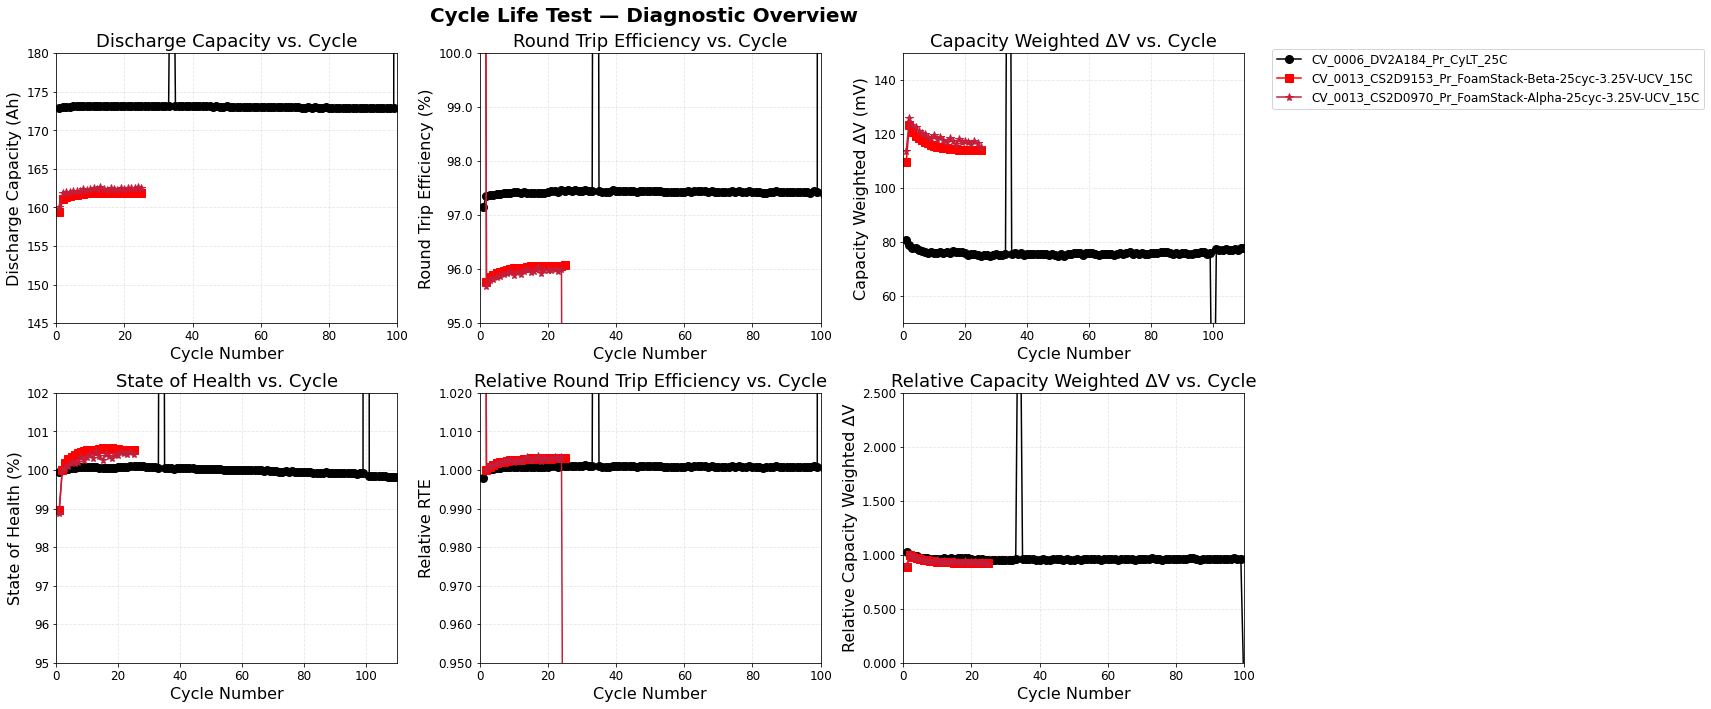

✅ Diagnostic figure complete.


In [8]:
# ================================================================
# CELL 7.5 — DIAGNOSTIC FIGURE (6 panels, 2×3)
# Place this cell BEFORE Cell 8 (the Excel export cell).
# Requires: cycle_series_summary (from Cell 5)
# ================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Helpers ---------------------------------------------------------

def _get_numeric(df, col):
    """Return column as float, coercing 'NAN' strings and non-numeric to NaN."""
    return pd.to_numeric(df[col], errors='coerce')

# --- Cycle cutoff -----------------------------------------------------
# All panels will only plot data up through this cycle number.
#cycle cutoff
CYCLE_CUTOFF = 25
_baseline_test = test_names[0]  # black series — runs full length, no cutoff

_cycle_num = pd.to_numeric(cycle_series_summary['Cycle'], errors='coerce')
_is_baseline = cycle_series_summary['Test Name'] == _baseline_test

cycle_series_plot = cycle_series_summary[_is_baseline | (_cycle_num <= CYCLE_CUTOFF)]

# --- Color assignment by position -----------------------------------
# Edit hex codes to match your preferred palette.
# Position 0 = first test in test_names, position 1 = second, etc.
_hex_colors = [
    '#000000',  # position 0
    '#FF0000',  # position 1
    '#C41E3A',  # position 2
    #'#FFA500',  # position 3
    #'#E35335',  # position 4
    #'#DE3163',  # position 5
    #'#e377c2',  # position 6
    #'#7f7f7f',  # position 7
]
_test_color = {
    name: _hex_colors[i % len(_hex_colors)]
    for i, name in enumerate(test_names)
}

_test_marker = {
    test_names[0]: 'o',   
    test_names[1]: 's',   
    test_names[2]: '*', 
   # test_names[3]: 'x',   
   # test_names[4]: '^', 
}

# --- Figure layout ---------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Cycle Life Test — Diagnostic Overview', fontsize=20, fontweight='bold')

# ----------------------------------------------------------------
# PANEL 1 — Discharge Capacity vs. Cycle
# ----------------------------------------------------------------
ax1 = axes[0, 0]
for _test_name, _grp in cycle_series_plot.groupby('Test Name', sort=False):
    ax1.plot(
        _grp['Cycle'],
        _get_numeric(_grp, 'Discharge capacity (Ah)'),
        color=_test_color.get(_test_name, 'gray'),
        linewidth=1.5, marker=_test_marker.get(_test_name, 'o'), markersize=8,
        label=_test_name,
    )
ax1.set_xlim(0,100)
ax1.set_ylim(145,180)
ax1.set_xlabel('Cycle Number', fontsize=16)
ax1.set_ylabel('Discharge Capacity (Ah)', fontsize=16)
ax1.set_title('Discharge Capacity vs. Cycle', fontsize=18)

# ----------------------------------------------------------------
# PANEL 2 — Round Trip Efficiency vs. Cycle
# ----------------------------------------------------------------
ax2 = axes[0, 1]
for _test_name, _grp in cycle_series_plot.groupby('Test Name', sort=False):
    ax2.plot(
        _grp['Cycle'],
        _get_numeric(_grp, 'Energy efficiency') * 100,
        color=_test_color.get(_test_name, 'gray'),
        linewidth=1.5, marker=_test_marker.get(_test_name, 'o'), markersize=8,
        label=_test_name,
    )
ax2.set_xlim(0,100)
ax2.set_ylim(95,100)
ax2.set_xlabel('Cycle Number', fontsize=16)
ax2.set_ylabel('Round Trip Efficiency (%)', fontsize=16)
ax2.set_title('Round Trip Efficiency vs. Cycle', fontsize=18)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# ----------------------------------------------------------------
# PANEL 3 — Capacity Weighted ΔV vs. Cycle
# ----------------------------------------------------------------
ax3 = axes[0, 2]
for _test_name, _grp in cycle_series_plot.groupby('Test Name', sort=False):
    ax3.plot(
        _grp['Cycle'],
        _get_numeric(_grp, 'Capacity weighted ΔV (mV)'),
        color=_test_color.get(_test_name, 'gray'),
        linewidth=1.5, marker=_test_marker.get(_test_name, 'o'), markersize=8,
        label=_test_name,
    )
ax3.set_xlim(0,110)
ax3.set_ylim(50,150)
ax3.set_xlabel('Cycle Number', fontsize=16)
ax3.set_ylabel('Capacity Weighted ΔV (mV)', fontsize=16)
ax3.set_title('Capacity Weighted ΔV vs. Cycle', fontsize=18)

# ----------------------------------------------------------------
# PANEL 4 — State of Health vs. Cycle
# ----------------------------------------------------------------
ax4 = axes[1, 0]
for _test_name, _grp in cycle_series_plot.groupby('Test Name', sort=False):
    ax4.plot(
        _grp['Cycle'],
        _get_numeric(_grp, 'Relative discharge capacity') * 100,
        color=_test_color.get(_test_name, 'gray'),
        linewidth=1.5, marker=_test_marker.get(_test_name, 'o'), markersize=8,
        label=_test_name,
    )
ax4.set_xlim(0,110)
ax4.set_ylim(95,102)
ax4.set_xlabel('Cycle Number', fontsize=16)
ax4.set_ylabel('State of Health (%)', fontsize=16)
ax4.set_title('State of Health vs. Cycle', fontsize=18)

# ----------------------------------------------------------------
# PANEL 5 — Relative Round Trip Efficiency vs. Cycle
# ----------------------------------------------------------------
ax5 = axes[1, 1]
for _test_name, _grp in cycle_series_plot.groupby('Test Name', sort=False):
    ax5.plot(
        _grp['Cycle'],
        _get_numeric(_grp, 'Relative energy efficiency'),
        color=_test_color.get(_test_name, 'gray'),
        linewidth=1.5, marker=_test_marker.get(_test_name, 'o'), markersize=8,
        label=_test_name,
    )
ax5.set_xlim(0,100)
ax5.set_ylim(0.95,1.02)
ax5.set_xlabel('Cycle Number', fontsize=16)
ax5.set_ylabel('Relative RTE', fontsize=16)
ax5.set_title('Relative Round Trip Efficiency vs. Cycle', fontsize=18)
ax5.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ----------------------------------------------------------------
# PANEL 6 — Relative Capacity Weighted ΔV vs. Cycle
# ----------------------------------------------------------------
ax6 = axes[1, 2]
for _test_name, _grp in cycle_series_plot.groupby('Test Name', sort=False):
    ax6.plot(
        _grp['Cycle'],
        _get_numeric(_grp, 'Relative capacity weighted ΔV'),
        color=_test_color.get(_test_name, 'gray'),
        linewidth=1.5, marker=_test_marker.get(_test_name, 'o'), markersize=8,
        label=_test_name,
    )
ax6.set_xlim(0,100)
ax6.set_ylim(0,2.5)
ax6.set_xlabel('Cycle Number', fontsize=16)
ax6.set_ylabel('Relative Capacity Weighted ΔV', fontsize=16)
ax6.set_title('Relative Capacity Weighted ΔV vs. Cycle', fontsize=18)
ax6.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ----------------------------------------------------------------
# Shared formatting
# ----------------------------------------------------------------
for _ax in axes.flat:
    _ax.grid(True, alpha=0.3, linestyle='--')
    _ax.tick_params(axis='both', labelsize=12)

# --- Single legend on the right side of the figure ---------------
_handles, _labels = ax1.get_legend_handles_labels()
fig.legend(
    _handles, _labels,
    loc='center left',
    bbox_to_anchor=(0.98, ax3.get_position().y1),
    fontsize=12,
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 0.98, 1])  # reserve space on right for legend
#plt.savefig('Master_TD_CS2D9153_Duplicate_E-chem_figs_v2.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Diagnostic figure complete.")

In [13]:
'''
# ================================================================
# CELL 8 — EXPORT ALL RESULTS TO EXCEL
# Output structure:
#   • One sheet per test — columns match MasterCode_Metrics_v1.xlsx
#     order (thickness excluded), one row per cycle, all missing
#     values shown as "NAN" for clean copy-paste into modeling file.
#   • One "DCIR Raw" sheet — full ΔV and resistance data across all
#     SOC levels and time points, for both charge and discharge.
# ================================================================
 
print(f"\n💾 Preparing export to '{output_filename}' ...")
 
# --- Step 1: Aggregate ambient temperature to mean per cycle ---
# Converts the raw time series into a single representative value
# per cycle to align with the per-cycle row structure.
ambient_per_cycle = (
    ambient_temp_summary
    .groupby(['Test Name', 'Cycle'], as_index=False)['Ambient temperature (°C)']
    .mean()
)
 
# --- Step 2: Isolate discharge DCIR summary and align column names ---
# Only discharge DCR values are included in the main output sheets.
dcir_discharge = (
    dcir_summary[dcir_summary['Charge/Discharge'] == 'Discharge']
    .copy()
    .rename(columns={'test_name': 'Test Name'})
)[['Test Name', 'Cycle',
   '10s DCR 50%SOC (mΩ)',     'SOC weighted 10s DCR (mΩ)',
   'Relative 10s DCR 50%SOC', 'Relative SOC weighted 10s DCR']]
 
# --- Step 3: Merge all data onto the cycle series base ---
# Left-join ensures every cycle row is preserved; cycles without
# DCIR or ambient data will naturally receive NaN (→ "NAN" below).
master_df = (
    cycle_series_summary
    .merge(ambient_per_cycle, on=['Test Name', 'Cycle'], how='left')
    .merge(dcir_discharge,    on=['Test Name', 'Cycle'], how='left')
)
 
# --- Step 4: Define output column order (matches reference Excel) ---
# Columns are listed in the exact order of MasterCode_Metrics_v1.xlsx,
# with thickness columns excluded per project decision.
output_column_order = [
    'Time (days)',
    'Cycle',
    'Charge capacity (Ah)',
    'Discharge capacity (Ah)',
    'Relative discharge capacity',
    'Coulombic efficiency',
    'Charge energy (Wh)',
    'Discharge energy (Wh)',
    'Relative discharge energy',
    'Energy efficiency',
    'Energy inefficiency',
    'Relative energy efficiency',
    'Relative energy inefficiency',
    'Time weighted ΔV (mV)',
    'Capacity weighted ΔV (mV)',
    'Relative time weighted ΔV',
    'Relative capacity weighted ΔV',
    '10s DCR 50%SOC (mΩ)',
    'SOC weighted 10s DCR (mΩ)',
    'Relative 10s DCR 50%SOC',
    'Relative SOC weighted 10s DCR',
    'Ambient temperature (°C)',
    'Max charge temperature (°C)',
    'Max discharge temperature (°C)',
    'Thickness (mm)',
    'Relative thickness',
]
 
# --- Step 5: Guarantee every output column exists ---
# If an analysis was skipped (e.g. run_dcir = False) its columns may
# not have been added by the merge. Add any missing columns as None
# so they always appear in the output, then fill all NaN with "NAN".
for col in output_column_order:
    if col not in master_df.columns:
        master_df[col] = None
 
for col in output_column_order:
    master_df[col] = master_df[col].fillna('NAN')
 
# --- Step 6: Write one sheet per test ---
print(f"\n💾 Writing to '{output_filename}' ...")
 
with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
 
    for test_name, group in master_df.groupby('Test Name', sort=False):
 
        # Select only reference-ordered columns that exist in the DataFrame.
        sheet_df = (
            group[[c for c in output_column_order if c in group.columns]]
            .reset_index(drop=True)
        )
 
        # Excel sheet names are limited to 31 characters.
        sheet_name = str(test_name)[:31]
        sheet_df.to_excel(writer, sheet_name=sheet_name, index=False)
        print(f"  ✅ {sheet_name}")
 
    # Append a DCIR Raw sheet for reference and deeper analysis.
    dcir_raw_cols = [
        'test_name', 'cycle', 'Charge/Discharge', 'SOC_label', 'SOC',
        'V_0s', 'V_1s', 'V_10s', 'V_60s',
        'ΔV_1s', 'ΔV_10s', 'ΔV_60s',
        'R_1s (mΩ)', 'R_10s (mΩ)', 'R_60s (mΩ)',
    ]
    combined_all[
        [c for c in dcir_raw_cols if c in combined_all.columns]
    ].fillna('NAN').to_excel(writer, sheet_name='DCIR Raw', index=False)
    print(f"  ✅ DCIR Raw")
 
print(f"\n✅ Export complete: {output_filename}")
print(f"   Sheets: one per test (cycle data) + DCIR Raw")

'''


💾 Preparing export to 'battery_analysis_results_v10.xlsx' ...

💾 Writing to 'battery_analysis_results_v10.xlsx' ...
  ✅ CV_0005_CS1B8317_Pr_CyLT_25C
  ✅ CV_0005_CS1B8739_Pr_CyLT_45C
  ✅ DCIR Raw

✅ Export complete: battery_analysis_results_v10.xlsx
   Sheets: one per test (cycle data) + DCIR Raw
